# 05h — Model H Training: Delta + Monte Carlo Simulation

Predicts **delta_ratio** (lap_time_ratio - field_median_ratio) to cancel
systematic bias. Monte Carlo (N=200) averages out random errors.

Same 25 features as Model F, different target + MC inference.

CV: ExpandingWindowSplit (2019→2020 ... 2019-23→2024 test).

## 0. Setup

In [1]:
import os
from pathlib import Path

if not (Path.cwd() / "pyproject.toml").exists():
    # We're likely in notebooks/ — go up to repo root
    for p in [Path.cwd().parent, Path.cwd().parent.parent]:
        if (p / "pyproject.toml").exists():
            os.chdir(p)
            break

print(f"Working directory: {Path.cwd()}")

Working directory: /opt/f1-training


In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import lightgbm as lgb

from f1_predictor.features.splits import ExpandingWindowSplit, LeaveOneSeasonOut
from f1_predictor.data.storage import (
    load_from_gcs_or_local,
    load_training_parquet,
    save_training_parquet,
    save_model_pickle as gcs_save_model_pickle,
    save_notebook,
    sync_training_from_gcs,
)
from f1_predictor.models.gpu import (
    detect_gpu_backend, get_lightgbm_device, get_torch_device, get_xgboost_device,
)

warnings.filterwarnings("ignore", category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

TRAINING_DIR = Path("data/training")
MODEL_DIR = Path("data/raw/model")
TRAINING_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# GPU detection (supports NVIDIA CUDA and AMD ROCm)
GPU_BACKEND, GPU_NAME = detect_gpu_backend()
TORCH_DEVICE = get_torch_device()
print(f"GPU backend: {GPU_BACKEND} ({GPU_NAME})")
print(f"PyTorch device: {TORCH_DEVICE}")

# Deep learning models (PyTorch — works on both CUDA and ROCm via HIP)
DL_AVAILABLE = False
try:
    from f1_predictor.models.architectures import GRU2Layer, FTTransformerWrapper, MLP3Layer
    DL_AVAILABLE = TORCH_DEVICE != "cpu"
    print(f"DL models available: {DL_AVAILABLE}")
except (ImportError, NameError):
    print("DL models not available (torch/rtdl not installed)")

GPU backend: cuda (Tesla V100-SXM2-16GB)
PyTorch device: cuda
DL models available: True


In [3]:
def save_predictions(model, X, y, id_df, model_type, model_name, split_name):
    """Save prediction parquet locally and to GCS."""
    preds = model.predict(X)
    out = id_df.copy()
    out["y_true"] = y.values
    out["y_pred"] = preds
    fname = f"model_{model_type}_{model_name}_{split_name}.parquet"
    uri = save_training_parquet(out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")
    return preds


def save_model_pkl(model, model_type, model_name):
    """Save model pickle locally and to GCS."""
    fname = f"Model_{model_type}_{model_name}.pkl"
    uri = gcs_save_model_pickle(model, fname, MODEL_DIR)
    print(f"  Saved {fname} -> {uri}")

In [4]:
import sys
from datetime import datetime, timezone

class ProgressLogger:
    def __init__(self, model_key, log_dir="/var/log"):
        self.model_key = model_key
        self.log_path = f"{log_dir}/f1-model-{model_key.lower()}-progress.log"
        try:
            self._f = open(self.log_path, "a", buffering=1)
        except OSError:
            self._f = None

    def log(self, msg):
        ts = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")
        line = f"[Model {self.model_key}] [{ts}] {msg}"
        print(line, flush=True)
        if self._f:
            self._f.write(line + "\n")
            self._f.flush()

    def round_header(self, round_num, desc):
        self.log(f"========== ROUND {round_num}: {desc} ==========")

    def screening(self, name, idx, total, rmse=None, error=None):
        if error:
            self.log(f"Screening {idx}/{total} {name} -- FAILED: {error}")
        else:
            self.log(f"Screening {idx}/{total} {name} -- RMSE: {rmse:.6f}")

    def optuna_trial(self, name, trial_num, total, rmse, best_rmse):
        self.log(f"{name} trial {trial_num}/{total} -- RMSE: {rmse:.6f} (best: {best_rmse:.6f})")

    def model_complete(self, name, round_num, rmse):
        self.log(f"{name} Round {round_num} COMPLETE -- best RMSE: {rmse:.6f}")

    def close(self):
        if self._f:
            self._f.close()

progress = ProgressLogger("H")

In [5]:
import json as _json_slack
import os as _os_slack
from urllib.request import Request as _SlackReq, urlopen as _slack_urlopen

class SlackNotifier:
    def __init__(self, model_key):
        self.model_key = model_key
        self.webhook_url = _os_slack.environ.get("SLACK_WEBHOOK_URL", "")
        self.enabled = bool(self.webhook_url)

    def send(self, text):
        if not self.enabled:
            return
        try:
            data = _json_slack.dumps({"text": text}).encode()
            req = _SlackReq(self.webhook_url, data=data,
                            headers={"Content-Type": "application/json"})
            _slack_urlopen(req, timeout=10)
        except Exception:
            pass

    def round_start(self, round_num, desc, n_models):
        self.send(f":racing_car: *Model {self.model_key} -- Round {round_num}*\n{desc} ({n_models} models)")

    def round_complete(self, round_num, summary):
        self.send(f":checkered_flag: *Model {self.model_key} -- Round {round_num} complete*\n{summary}")

    def model_start(self):
        self.send(f":rocket: *Model {self.model_key} training STARTED*")

    def model_complete(self, best_model, best_rmse):
        self.send(f":tada: *Model {self.model_key} training COMPLETE*\nBest: {best_model} (RMSE: {best_rmse:.6f})")

    def architecture_done(self, name, round_num, rmse):
        self.send(f":gear: Model {self.model_key} R{round_num} -- {name} done (RMSE: {rmse:.6f})")

    def error(self, context, error_msg):
        self.send(f":rotating_light: *Model {self.model_key} ERROR* -- {context}: {error_msg}")

slack = SlackNotifier("H")

In [6]:
import json as _json_ckpt
import subprocess as _sp_ckpt
from datetime import datetime as _dt_ckpt, timezone as _tz_ckpt
from pathlib import Path as _Path_ckpt

class CheckpointManager:
    def __init__(self, model_key, local_base="/opt/f1-training/checkpoints",
                 bucket="f1-predictor-artifacts-jowin",
                 gcs_prefix="staging/training-run/checkpoints"):
        self.model_key = model_key
        self.local_dir = _Path_ckpt(local_base) / f"model_{model_key}"
        self.local_dir.mkdir(parents=True, exist_ok=True)
        self.gcs_prefix = f"gs://{bucket}/{gcs_prefix}/model_{model_key}"
        self._sync_from_gcs()

    def _sync_from_gcs(self):
        try:
            _sp_ckpt.run(
                ["gsutil", "-m", "-q", "cp", "-r",
                 f"{self.gcs_prefix}/*", str(self.local_dir) + "/"],
                capture_output=True, timeout=60)
        except Exception:
            pass

    def _upload(self, local_path):
        name = _Path_ckpt(local_path).name
        try:
            _sp_ckpt.run(
                ["gsutil", "-q", "cp", str(local_path),
                 f"{self.gcs_prefix}/{name}"],
                capture_output=True, timeout=30)
        except Exception:
            pass

    def save_checkpoint(self, round_num, arch_name, rmse, best_params, **extra):
        data = {
            "model_key": self.model_key,
            "round": round_num,
            "architecture": arch_name,
            "rmse": rmse,
            "best_params": best_params,
            "timestamp": _dt_ckpt.now(_tz_ckpt.utc).isoformat(),
            **extra,
        }
        path = self.local_dir / f"round_{round_num}_{arch_name}.json"
        path.write_text(_json_ckpt.dumps(data, indent=2, default=str))
        self._upload(path)

    def load_checkpoint(self, round_num, arch_name):
        path = self.local_dir / f"round_{round_num}_{arch_name}.json"
        if path.exists():
            return _json_ckpt.loads(path.read_text())
        return None

    def get_completed(self, round_num):
        result = {}
        for p in sorted(self.local_dir.glob(f"round_{round_num}_*.json")):
            if p.stem.endswith("_summary"):
                continue
            data = _json_ckpt.loads(p.read_text())
            result[data["architecture"]] = data
        return result

    def save_round_summary(self, round_num, results_list, top_names):
        data = {"round": round_num, "results": results_list, "top_names": top_names,
                "timestamp": _dt_ckpt.now(_tz_ckpt.utc).isoformat()}
        path = self.local_dir / f"round_{round_num}_summary.json"
        path.write_text(_json_ckpt.dumps(data, indent=2, default=str))
        self._upload(path)

    def load_round_summary(self, round_num):
        path = self.local_dir / f"round_{round_num}_summary.json"
        if path.exists():
            return _json_ckpt.loads(path.read_text())
        return None

ckpt = CheckpointManager("H")

In [7]:
slack.model_start()
progress.log('Starting Model H training')

[Model H] [2026-04-29 08:18:09 UTC] Starting Model H training


## 1. Build Training Data (Delta Target)

In [8]:
from f1_predictor.features.simulation_features import (
    build_simulation_training_data,
    SIMULATION_FEATURE_COLS,
)
from f1_predictor.features.delta_features import (
    build_field_median_curves,
    build_delta_training_data,
)

laps = load_from_gcs_or_local(
    "data/raw/laps/all_laps.parquet",
    Path("data/raw/laps/all_laps.parquet"),
)
races = load_from_gcs_or_local(
    "data/raw/race/all_races.parquet",
    Path("data/raw/race/all_races.parquet"),
)

# Build base simulation features
df_base = build_simulation_training_data(laps, races)
print(f"Base shape: {df_base.shape}")

# Build field median curves and delta target
field_medians = build_field_median_curves(laps, races)
print(f"Circuits with median curves: {len(field_medians)}")

df = build_delta_training_data(df_base, field_medians, races)
print(f"Delta shape: {df.shape}")
print(f"delta_ratio stats:\n{df['delta_ratio'].describe()}")

Base shape: (78606, 31)
Circuits with median curves: 35


Delta shape: (78606, 34)
delta_ratio stats:
count    78606.000000
mean         0.014823
std          0.073008
min         -0.515243
25%         -0.009097
50%          0.000000
75%          0.010814
max          0.536339
Name: delta_ratio, dtype: float64


In [9]:
FEATURE_COLS = SIMULATION_FEATURE_COLS
TARGET = "delta_ratio"
ID_COLS = ["season", "round", "event_name", "driver_abbrev", "team"]

df = df.dropna(subset=[TARGET]).reset_index(drop=True)

X = df[FEATURE_COLS]
y = df[TARGET]
groups = df["season"].values
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"NaN counts:\n{X.isna().sum()}")

Features (25): ['grid_position', 'best_quali_sec', 'circuit_street', 'circuit_hybrid', 'circuit_permanent', 'lap_number', 'race_progress_pct', 'compound_HARD', 'compound_INTERMEDIATE', 'compound_MEDIUM', 'compound_SOFT', 'compound_WET', 'tire_life', 'stint', 'is_pit_in_lap', 'is_pit_out_lap', 'pit_stop_count', 'laps_since_last_pit', 'lap_time_rolling_3', 'lap_time_rolling_5', 'degradation_rate', 'gap_to_leader', 'position', 'position_change_from_lap1', 'is_caution']
X shape: (78606, 25), y shape: (78606,)
NaN counts:
grid_position                    0
best_quali_sec                   0
circuit_street                   0
circuit_hybrid                   0
circuit_permanent                0
lap_number                       0
race_progress_pct                0
compound_HARD                    0
compound_INTERMEDIATE            0
compound_MEDIUM                  0
compound_SOFT                    0
compound_WET                     0
tire_life                      205
stint                 

## 2. CV Splitter

In [10]:
splitter = ExpandingWindowSplit(
    fold_definitions=[
        ([2019], 2020),
        ([2019, 2020], 2021),
        ([2019, 2020, 2021], 2022),
        ([2019, 2020, 2021, 2022], 2023),
    ],
    test_season=2024,
)
print(f"CV folds: {splitter.get_n_splits()}")
for i, (tr, va) in enumerate(splitter.split(groups)):
    tr_seasons = sorted(set(groups[tr]))
    va_seasons = sorted(set(groups[va]))
    print(f"  Fold {i}: train seasons={tr_seasons}, val seasons={va_seasons}, "
          f"train={len(tr):,}, val={len(va):,}")

CV folds: 4
  Fold 0: train seasons=[np.int64(2019)], val seasons=[np.int64(2020)], train=22,496, val=15,483
  Fold 1: train seasons=[np.int64(2019), np.int64(2020)], val seasons=[np.int64(2021)], train=37,979, val=22,112
  Fold 2: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021)], val seasons=[np.int64(2022)], train=60,091, val=10,038
  Fold 3: train seasons=[np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)], val seasons=[np.int64(2023)], train=70,129, val=3,690


## 3. Model Candidates and Helpers

9 GPU candidates: 6 tree-based + 3 DL, all on delta target.
DL models are Optuna-tunable (no skip).

In [11]:
NAN_TOLERANT = {
    "XGBoost_Delta", "XGBoost_DART_Delta", "XGBoost_Deep_Delta",
    "LightGBM_Delta", "LightGBM_GOSS_Delta", "LightGBM_Shallow_Delta",
}

DL_SKIP_OPTUNA = set()  # all models tunable

def get_candidates_h():
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)
    candidates = {
        "XGBoost_Delta": xgb.XGBRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "XGBoost_DART_Delta": xgb.XGBRegressor(
            n_estimators=300, booster="dart", n_jobs=-1,
            random_state=42, verbosity=0, **xgb_device),
        "XGBoost_Deep_Delta": xgb.XGBRegressor(
            n_estimators=300, max_depth=10, learning_rate=0.1,
            n_jobs=-1, random_state=42, verbosity=0, **xgb_device),
        "LightGBM_Delta": lgb.LGBMRegressor(
            n_estimators=300, n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
        "LightGBM_GOSS_Delta": lgb.LGBMRegressor(
            n_estimators=300, boosting_type="goss", n_jobs=-1,
            random_state=42, verbose=-1, **lgb_device),
        "LightGBM_Shallow_Delta": lgb.LGBMRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            n_jobs=-1, random_state=42, verbose=-1, **lgb_device),
    }
    if DL_AVAILABLE:
        n_feat = len(FEATURE_COLS)
        candidates["GRU_Delta"] = GRU2Layer(input_dim=n_feat)
        candidates["FTTransformer_Delta"] = FTTransformerWrapper(n_features=n_feat)
        candidates["MLP_Delta"] = MLP3Layer(input_dim=n_feat, hidden1=128, hidden2=64)
    print(f"Candidates ({len(candidates)}): {list(candidates.keys())}")
    return candidates

MODEL_CLASSES_H = {
    "XGBoost_Delta": xgb.XGBRegressor,
    "XGBoost_DART_Delta": xgb.XGBRegressor,
    "XGBoost_Deep_Delta": xgb.XGBRegressor,
    "LightGBM_Delta": lgb.LGBMRegressor,
    "LightGBM_GOSS_Delta": lgb.LGBMRegressor,
    "LightGBM_Shallow_Delta": lgb.LGBMRegressor,
}
if DL_AVAILABLE:
    MODEL_CLASSES_H.update({
        "GRU_Delta": GRU2Layer,
        "FTTransformer_Delta": FTTransformerWrapper,
        "MLP_Delta": MLP3Layer,
    })

def _xgb_base_space_h(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def _lgb_base_space_h(trial):
    return dict(
        n_estimators=trial.suggest_int("n_estimators", 100, 1500),
        max_depth=trial.suggest_int("max_depth", 3, 12),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    )

def _dl_base_space_h(trial, model_cls):
    params = dict(
        input_dim=len(FEATURE_COLS),
    )
    if model_cls == MLP3Layer:
        params["hidden1"] = trial.suggest_categorical("hidden1", [64, 128, 256])
        params["hidden2"] = trial.suggest_categorical("hidden2", [32, 64, 128])
        params["dropout"] = trial.suggest_float("dropout", 0.1, 0.5)
        params["lr"] = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        params["weight_decay"] = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    else:
        params["hidden_dim"] = trial.suggest_categorical("hidden_dim", [32, 64, 128, 256])
        params["num_layers"] = trial.suggest_int("num_layers", 1, 3)
        params["dropout"] = trial.suggest_float("dropout", 0.05, 0.5)
        params["lr"] = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
        params["weight_decay"] = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    if model_cls == FTTransformerWrapper:
        params["n_features"] = len(FEATURE_COLS)
        params.pop("input_dim", None)
    return params

def get_optuna_param_space_h(name, trial):
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)
    if name.startswith("XGBoost"):
        params = _xgb_base_space_h(trial)
        if "DART" in name:
            params["booster"] = "dart"
            params["rate_drop"] = trial.suggest_float("rate_drop", 0.01, 0.5)
        if "Deep" in name:
            pass  # max_depth already in search space
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
        return params
    elif name.startswith("LightGBM"):
        params = _lgb_base_space_h(trial)
        if "GOSS" in name:
            params.pop("subsample", None)
            params["boosting_type"] = "goss"
        if "Shallow" in name:
            pass
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
        return params
    elif name in ("GRU_Delta", "FTTransformer_Delta", "MLP_Delta"):
        return _dl_base_space_h(trial, MODEL_CLASSES_H[name])
    return {}

def reconstruct_params_h(name, best_params):
    params = dict(best_params)
    xgb_device = get_xgboost_device(GPU_BACKEND)
    lgb_device = get_lightgbm_device(GPU_BACKEND)
    if name.startswith("XGBoost"):
        if "DART" in name:
            params.setdefault("booster", "dart")
        params.update(n_jobs=-1, random_state=42, verbosity=0, **xgb_device)
    elif name.startswith("LightGBM"):
        if "GOSS" in name:
            params.pop("subsample", None)
            params["boosting_type"] = "goss"
        params.update(n_jobs=-1, random_state=42, verbose=-1, **lgb_device)
    return params

In [12]:
def cv_evaluate_h(model, X, y, splitter, groups):
    from sklearn.metrics import mean_squared_error, mean_absolute_error
    rmses, maes = [], []
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        m = sklearn.base.clone(model)
        X_tr = X.iloc[tr_idx] if hasattr(X, "iloc") else X[tr_idx]
        y_tr = y.iloc[tr_idx] if hasattr(y, "iloc") else y[tr_idx]
        X_va = X.iloc[va_idx] if hasattr(X, "iloc") else X[va_idx]
        y_va = y.iloc[va_idx] if hasattr(y, "iloc") else y[va_idx]
        name_str = type(model).__name__
        if name_str in str(NAN_TOLERANT) or any(n in str(type(model)) for n in ["XGB", "LGB"]):
            m.fit(X_tr, y_tr)
        else:
            X_tr_clean = X_tr.fillna(0) if hasattr(X_tr, "fillna") else np.nan_to_num(X_tr)
            X_va_clean = X_va.fillna(0) if hasattr(X_va, "fillna") else np.nan_to_num(X_va)
            m.fit(X_tr_clean, y_tr)
            X_va = X_va_clean
        preds = m.predict(X_va)
        rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        maes.append(mean_absolute_error(y_va, preds))
    return {"mean_rmse": np.mean(rmses), "std_rmse": np.std(rmses), "mean_mae": np.mean(maes)}

def screen_models_h(candidates, X, y, splitter, groups):
    rows = []
    completed = ckpt.get_completed(1)
    total = len(candidates)
    for idx, (name, model) in enumerate(candidates.items(), 1):
        if name in completed:
            cp = completed[name]
            rows.append({"model": name, "mean_rmse": cp["rmse"],
                         "std_rmse": cp.get("std_rmse", 0), "mean_mae": cp.get("mean_mae", 0)})
            progress.log(f"Screening {idx}/{total} {name} -- RESUMED (RMSE: {cp['rmse']:.6f})")
            continue
        try:
            result = cv_evaluate_h(model, X, y, splitter, groups)
            rows.append({"model": name, **result})
            progress.screening(name, idx, total, rmse=result["mean_rmse"])
            ckpt.save_checkpoint(1, name, result["mean_rmse"], {},
                                 std_rmse=result["std_rmse"], mean_mae=result["mean_mae"])
        except Exception as e:
            progress.screening(name, idx, total, error=str(e))
            slack.error(f"R1 screening {name}", str(e))
    if not rows:
        raise RuntimeError("All candidates failed — check data for NaN or shape issues")
    return pd.DataFrame(rows).sort_values("mean_rmse").reset_index(drop=True)

def run_optuna_round_h(name, X, y, splitter, groups, n_trials):
    def objective(trial):
        params = get_optuna_param_space_h(name, trial)
        model_cls = MODEL_CLASSES_H[name]
        model = model_cls(**params)
        result = cv_evaluate_h(model, X, y, splitter, groups)
        return result["mean_rmse"]
    def _trial_cb(study, trial):
        if trial.value is not None:
            progress.optuna_trial(name, trial.number + 1, n_trials, trial.value, study.best_value)
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials, catch=(Exception,), show_progress_bar=False,
                   callbacks=[_trial_cb])
    return study.best_params, study.best_value

## 4. Round 1 — Screen Models

In [13]:
progress.round_header(1, "Screen all candidates")
slack.round_start(1, "Screening all candidates", len(get_candidates_h()))
candidates = get_candidates_h()
r1_results = screen_models_h(candidates, X, y, splitter, groups)
ckpt.save_round_summary(1, r1_results.to_dict("records"), r1_results["model"].head(7).tolist())
slack.round_complete(1, f"Best: {r1_results.iloc[0]['model']} (RMSE: {r1_results.iloc[0]['mean_rmse']:.6f})")
r1_results[["model", "mean_rmse", "std_rmse", "mean_mae"]]

[Model H] [2026-04-29 08:18:25 UTC] ========== ROUND 1: Screen all candidates ==========


Candidates (9): ['XGBoost_Delta', 'XGBoost_DART_Delta', 'XGBoost_Deep_Delta', 'LightGBM_Delta', 'LightGBM_GOSS_Delta', 'LightGBM_Shallow_Delta', 'GRU_Delta', 'FTTransformer_Delta', 'MLP_Delta']


Candidates (9): ['XGBoost_Delta', 'XGBoost_DART_Delta', 'XGBoost_Deep_Delta', 'LightGBM_Delta', 'LightGBM_GOSS_Delta', 'LightGBM_Shallow_Delta', 'GRU_Delta', 'FTTransformer_Delta', 'MLP_Delta']
[Model H] [2026-04-29 08:18:25 UTC] Screening 1/9 XGBoost_Delta -- RESUMED (RMSE: 0.070190)


[Model H] [2026-04-29 08:18:25 UTC] Screening 2/9 XGBoost_DART_Delta -- RESUMED (RMSE: 0.070190)


[Model H] [2026-04-29 08:18:25 UTC] Screening 3/9 XGBoost_Deep_Delta -- RESUMED (RMSE: 0.071838)


...

[Model H] [2026-04-29 08:18:25 UTC] Screening 6/9 LightGBM_Shallow_Delta -- RESUMED (RMSE: 0.064750)


[Model H] [2026-04-29 08:18:25 UTC] Screening 7/9 GRU_Delta -- RESUMED (RMSE: 0.066534)


[Model H] [2026-04-29 08:18:25 UTC] Screening 8/9 FTTransformer_Delta -- RESUMED (RMSE: 0.078681)


[Model H] [2026-04-29 08:18:25 UTC] Screening 9/9 MLP_Delta -- RESUMED (RMSE: 0.070936)


,model,mean_rmse,std_rmse,mean_mae
0,LightGBM_Shallow_Delta,0.064750,0.010306,0.031695
1,LightGBM_Delta,0.064787,0.009292,0.031974
2,LightGBM_GOSS_Delta,0.064992,0.008648,0.032227
3,GRU_Delta,0.066534,0.011686,0.031784
4,XGBoost_DART_Delta,0.070190,0.012467,0.036002
5,XGBoost_Delta,0.070190,0.012467,0.036002
6,MLP_Delta,0.070936,0.014715,0.034865
7,XGBoost_Deep_Delta,0.071838,0.011916,0.036389
8,FTTransformer_Delta,0.078681,0.025834,0.038647


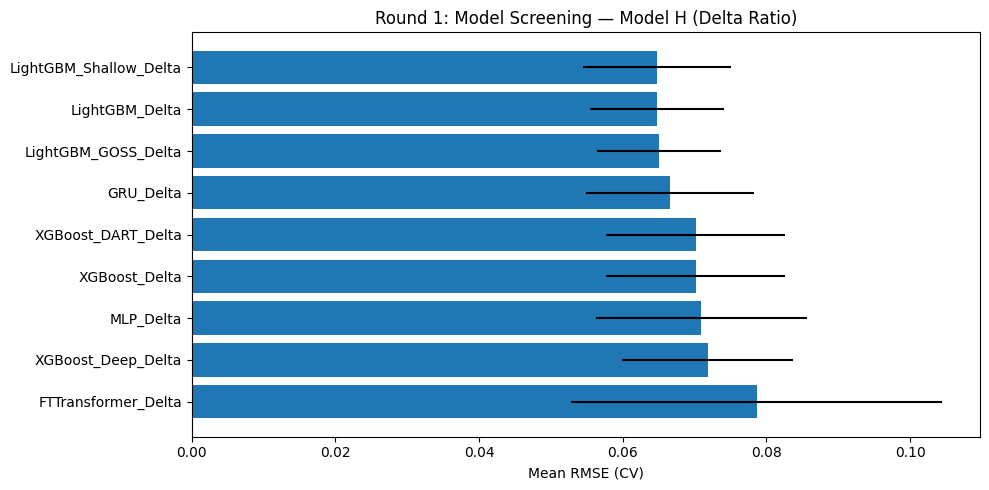

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(r1_results["model"], r1_results["mean_rmse"], xerr=r1_results["std_rmse"])
ax.set_xlabel("Mean RMSE (CV)")
ax.set_title("Round 1: Model Screening — Model H (Delta Ratio)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [15]:
r1_summary = ckpt.load_round_summary(1)
if r1_summary:
    top7_names = r1_summary["top_names"]
else:
    top7_names = r1_results["model"].head(7).tolist()
print(f"Advancing to Round 2: {top7_names}")
eliminated = [n for n in r1_results["model"].tolist() if n not in top7_names]
print(f"Eliminated: {eliminated}")

Advancing to Round 2: ['LightGBM_Shallow_Delta', 'LightGBM_Delta', 'LightGBM_GOSS_Delta', 'GRU_Delta', 'XGBoost_DART_Delta', 'XGBoost_Delta', 'MLP_Delta']
Eliminated: ['XGBoost_Deep_Delta', 'FTTransformer_Delta']


## 5. Round 2 — Optuna (top 7, 10 trials each)

In [16]:
progress.round_header(2, "Optuna HP tuning (top 7, 10 trials each)")
slack.round_start(2, "Optuna HP tuning", len(top7_names))
r2_results = []
completed_r2 = ckpt.get_completed(2)
for idx, name in enumerate(top7_names, 1):
    if name in completed_r2:
        cp = completed_r2[name]
        r2_results.append({"model": name, "best_rmse": cp["rmse"], "best_params": cp["best_params"]})
        progress.log(f"{name} -- RESUMED from checkpoint (RMSE: {cp['rmse']:.6f})")
        continue
    progress.log(f"Tuning {name} ({idx}/{len(top7_names)})...")
    try:
        best_params, best_rmse = run_optuna_round_h(name, X, y, splitter, groups, n_trials=10)
        r2_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
        ckpt.save_checkpoint(2, name, best_rmse, best_params)
        progress.model_complete(name, 2, best_rmse)
        slack.architecture_done(name, 2, best_rmse)
    except Exception as e:
        progress.log(f"{name} FAILED in Round 2: {e}")
        slack.error(f"R2 {name}", str(e))

r2_df = pd.DataFrame(r2_results).sort_values("best_rmse").reset_index(drop=True)
ckpt.save_round_summary(2, r2_results, r2_df["model"].head(5).tolist())
slack.round_complete(2, f"Top 5: {r2_df['model'].head(5).tolist()}")
r2_df[["model", "best_rmse"]]

[Model H] [2026-04-29 08:18:28 UTC] ========== ROUND 2: Optuna HP tuning (top 7, 10 trials each) ==========


[Model H] [2026-04-29 08:18:28 UTC] LightGBM_Shallow_Delta -- RESUMED from checkpoint (RMSE: 0.063710)


[Model H] [2026-04-29 08:18:28 UTC] LightGBM_Delta -- RESUMED from checkpoint (RMSE: 0.063736)


[Model H] [2026-04-29 08:18:28 UTC] LightGBM_GOSS_Delta -- RESUMED from checkpoint (RMSE: 0.063515)


[Model H] [2026-04-29 08:18:28 UTC] GRU_Delta -- RESUMED from checkpoint (RMSE: 0.066316)


[Model H] [2026-04-29 08:18:28 UTC] XGBoost_DART_Delta -- RESUMED from checkpoint (RMSE: 0.064982)


[Model H] [2026-04-29 08:18:28 UTC] XGBoost_Delta -- RESUMED from checkpoint (RMSE: 0.062530)


[Model H] [2026-04-29 08:18:28 UTC] MLP_Delta -- RESUMED from checkpoint (RMSE: 0.068592)


,model,best_rmse
0,XGBoost_Delta,0.062530
1,LightGBM_GOSS_Delta,0.063515
2,LightGBM_Shallow_Delta,0.063710
3,LightGBM_Delta,0.063736
4,XGBoost_DART_Delta,0.064982
5,GRU_Delta,0.066316
6,MLP_Delta,0.068592


In [17]:
r2_summary = ckpt.load_round_summary(2)
if r2_summary:
    top5_names = r2_summary["top_names"]
else:
    top5_names = r2_df["model"].head(5).tolist()
r2_best_params = {row["model"]: row["best_params"] for _, row in r2_df.iterrows() if "best_params" in row}
print(f"Advancing to Round 3: {top5_names}")

Advancing to Round 3: ['XGBoost_Delta', 'LightGBM_GOSS_Delta', 'LightGBM_Shallow_Delta', 'LightGBM_Delta', 'XGBoost_DART_Delta']


## 6. Round 3 — Final Tuning (top 5, 15 trials each)

In [18]:
progress.round_header(3, "Final tuning (top 5, 15 trials each)")
slack.round_start(3, "Final Optuna tuning", len(top5_names))
r3_results = []
completed_r3 = ckpt.get_completed(3)
for idx, name in enumerate(top5_names, 1):
    if name in completed_r3:
        cp = completed_r3[name]
        r3_results.append({"model": name, "best_rmse": cp["rmse"], "best_params": cp["best_params"]})
        progress.log(f"{name} -- RESUMED from checkpoint (RMSE: {cp['rmse']:.6f})")
        continue
    progress.log(f"Fine-tuning {name} ({idx}/{len(top5_names)})...")
    try:
        best_params, best_rmse = run_optuna_round_h(name, X, y, splitter, groups, n_trials=15)
        r3_results.append({"model": name, "best_rmse": best_rmse, "best_params": best_params})
        ckpt.save_checkpoint(3, name, best_rmse, best_params)
        progress.model_complete(name, 3, best_rmse)
        slack.architecture_done(name, 3, best_rmse)
    except Exception as e:
        progress.log(f"{name} FAILED in Round 3: {e}")
        slack.error(f"R3 {name}", str(e))

r3_df = pd.DataFrame(r3_results).sort_values("best_rmse").reset_index(drop=True)
r3_best_params = {row["model"]: row["best_params"] for _, row in r3_df.iterrows() if "best_params" in row}
ckpt.save_round_summary(3, r3_results, r3_df["model"].head(5).tolist())
slack.round_complete(3, f"Best: {r3_df.iloc[0]['model']} (RMSE: {r3_df.iloc[0]['best_rmse']:.6f})")
r3_df[["model", "best_rmse"]]

[Model H] [2026-04-29 08:18:31 UTC] ========== ROUND 3: Final tuning (top 5, 15 trials each) ==========


[Model H] [2026-04-29 08:18:31 UTC] XGBoost_Delta -- RESUMED from checkpoint (RMSE: 0.062530)


[Model H] [2026-04-29 08:18:31 UTC] LightGBM_GOSS_Delta -- RESUMED from checkpoint (RMSE: 0.062630)


[Model H] [2026-04-29 08:18:31 UTC] LightGBM_Shallow_Delta -- RESUMED from checkpoint (RMSE: 0.063427)


[Model H] [2026-04-29 08:18:31 UTC] LightGBM_Delta -- RESUMED from checkpoint (RMSE: 0.063380)


[Model H] [2026-04-29 08:18:31 UTC] XGBoost_DART_Delta -- RESUMED from checkpoint (RMSE: 0.064361)


,model,best_rmse
0,XGBoost_Delta,0.062530
1,LightGBM_GOSS_Delta,0.062630
2,LightGBM_Delta,0.063380
3,LightGBM_Shallow_Delta,0.063427
4,XGBoost_DART_Delta,0.064361


## 7. Test Set Evaluation (Per-Lap Delta)

In [19]:
train_idx, test_idx = splitter.get_test_split(groups)
X_train_full, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train_full, y_test = y.iloc[train_idx], y.iloc[test_idx]
id_train, id_test = df[ID_COLS].iloc[train_idx], df[ID_COLS].iloc[test_idx]

print(f"Train: {X_train_full.shape}, Test: {X_test.shape}")
print(f"Test season(s): {sorted(df['season'].iloc[test_idx].unique())}")

Train: (73819, 25), Test: (4787, 25)
Test season(s): [np.int64(2024)]


In [20]:
final_results = []
for name in top5_names:
    params = reconstruct_params_h(name, r3_best_params[name])
    model_cls = MODEL_CLASSES_H[name]
    model = model_cls(**params)
    model.fit(X_train_full, y_train_full)

    train_preds = model.predict(X_train_full)
    train_rmse = np.sqrt(mean_squared_error(y_train_full, train_preds))

    test_preds = model.predict(X_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))

    val_rmse = r3_df.loc[r3_df["model"] == name, "best_rmse"].values[0]

    final_results.append({
        "model": name,
        "train_rmse": train_rmse, "val_rmse": val_rmse,
        "test_rmse": test_rmse, "overfit_gap": test_rmse - val_rmse,
    })

    print(f"{name}: train_rmse={train_rmse:.4f}, val_rmse={val_rmse:.4f}, "
          f"test_rmse={test_rmse:.4f}, gap={test_rmse - val_rmse:.4f}")

final_df = pd.DataFrame(final_results).sort_values("test_rmse").reset_index(drop=True)
final_df

XGBoost_Delta: train_rmse=0.0404, val_rmse=0.0625, test_rmse=0.0226, gap=-0.0399


LightGBM_GOSS_Delta: train_rmse=0.0406, val_rmse=0.0626, test_rmse=0.0220, gap=-0.0406


LightGBM_Shallow_Delta: train_rmse=0.0402, val_rmse=0.0634, test_rmse=0.0228, gap=-0.0407


LightGBM_Delta: train_rmse=0.0402, val_rmse=0.0634, test_rmse=0.0228, gap=-0.0406


XGBoost_DART_Delta: train_rmse=0.0323, val_rmse=0.0644, test_rmse=0.0221, gap=-0.0422


,model,train_rmse,val_rmse,test_rmse,overfit_gap
0,LightGBM_GOSS_Delta,0.040589,0.062630,0.022022,-0.040607
1,XGBoost_DART_Delta,0.032339,0.064361,0.022127,-0.042234
2,XGBoost_Delta,0.040381,0.062530,0.022610,-0.039920
3,LightGBM_Shallow_Delta,0.040157,0.063427,0.022758,-0.040669
4,LightGBM_Delta,0.040157,0.063380,0.022758,-0.040622


## 8. Fit Residual Distribution for Monte Carlo

In [21]:
# Compute OOF residuals to calibrate MC noise
best_model_name = final_df.iloc[0]["model"]
best_params = reconstruct_params_h(best_model_name, r3_best_params[best_model_name])
best_model = MODEL_CLASSES_H[best_model_name](**best_params)

oof_residuals = np.full(len(X), np.nan)
for tr_idx, va_idx in splitter.split(groups):
    import sklearn.base
    fold_model = sklearn.base.clone(best_model)
    fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    preds = fold_model.predict(X.iloc[va_idx])
    oof_residuals[va_idx] = y.iloc[va_idx].values - preds

valid_mask = ~np.isnan(oof_residuals)
residual_std = float(np.std(oof_residuals[valid_mask]))
print(f"OOF residual std: {residual_std:.6f}")
print(f"This will be used as noise_std for Monte Carlo simulation")

OOF residual std: 0.059547
This will be used as noise_std for Monte Carlo simulation


## 9. Full Simulation — Delta + Monte Carlo (2024 Test Races)

In [22]:
from f1_predictor.simulation.delta_simulator import DeltaRaceSimulator, MonteCarloSimulator
from f1_predictor.simulation.defaults import build_circuit_defaults
from f1_predictor.simulation.evaluation import evaluate_simulation, evaluate_monte_carlo_calibration
from f1_predictor.features.race_features import LOCATION_ALIASES

circuit_defaults = build_circuit_defaults(laps)

# Retrain best model on full training set
best_model = MODEL_CLASSES_H[best_model_name](**best_params)
best_model.fit(X_train_full, y_train_full)

# Create delta simulator
delta_sim = DeltaRaceSimulator(best_model, circuit_defaults, field_medians)
mc_sim = MonteCarloSimulator(delta_sim, n_simulations=200, noise_std=residual_std, seed=42)

print(f"Simulator ready: {best_model_name}")
print(f"MC noise_std: {residual_std:.6f}, N=200 runs")

Simulator ready: LightGBM_GOSS_Delta
MC noise_std: 0.059547, N=200 runs


In [23]:
test_races = races[races["season"] == 2024].copy()
test_race_list = test_races.groupby(["season", "round", "event_name"]).first().reset_index()

# Single-run delta simulation
sim_results = []
# MC simulation
mc_results_all = []

for _, race_row in test_race_list.iterrows():
    event = race_row["event_name"]
    event_norm = LOCATION_ALIASES.get(event, event)

    if event_norm not in circuit_defaults:
        print(f"  Skipping {event} (no circuit data)")
        continue

    race_drivers = test_races[
        (test_races["season"] == race_row["season"])
        & (test_races["round"] == race_row["round"])
    ].copy()

    drivers_input = []
    actual_positions = {}
    for _, drv in race_drivers.iterrows():
        q1 = drv.get("q1_time_sec")
        q2 = drv.get("q2_time_sec")
        q3 = drv.get("q3_time_sec")
        q_times = [t for t in [q1, q2, q3] if pd.notna(t)]
        if not q_times or pd.isna(drv.get("grid_position")):
            continue
        drivers_input.append({
            "driver": drv["driver_abbrev"],
            "grid_position": int(drv["grid_position"]),
            "q1": q1 if pd.notna(q1) else None,
            "q2": q2 if pd.notna(q2) else None,
            "q3": q3 if pd.notna(q3) else None,
            "initial_tyre": "MEDIUM",
        })
        if pd.notna(drv.get("finish_position")):
            actual_positions[drv["driver_abbrev"]] = int(drv["finish_position"])

    if len(drivers_input) < 10:
        continue

    try:
        # Single-run delta
        result = delta_sim.simulate(event_norm, drivers_input)
        for fr in result.final_results:
            if fr["driver"] in actual_positions:
                sim_results.append({
                    "event": event, "driver": fr["driver"],
                    "predicted_pos": fr["position"],
                    "actual_pos": actual_positions[fr["driver"]],
                })

        # Monte Carlo
        mc_result = mc_sim.simulate(event_norm, drivers_input)
        for r in mc_result.results:
            if r["driver"] in actual_positions:
                mc_results_all.append({
                    **r, "event": event,
                    "actual_pos": actual_positions[r["driver"]],
                    "predicted_pos": r["position"],
                })
        print(f"  {event}: simulated {len(drivers_input)} drivers")
    except Exception as e:
        print(f"  {event}: failed — {e}")

sim_df = pd.DataFrame(sim_results)
mc_df = pd.DataFrame(mc_results_all)
print(f"\nSingle-run results: {len(sim_df)} driver-race predictions")
print(f"MC results: {len(mc_df)} driver-race predictions")

  Bahrain Grand Prix: simulated 20 drivers


  Emilia Romagna Grand Prix: simulated 19 drivers


  Hungarian Grand Prix: simulated 20 drivers


  Mexico City Grand Prix: simulated 20 drivers

Single-run results: 79 driver-race predictions
MC results: 79 driver-race predictions


In [24]:
from f1_predictor.simulation.evaluation import evaluate_simulation, evaluate_monte_carlo_calibration

# Single-run delta metrics
if len(sim_df) > 0:
    delta_metrics = evaluate_simulation(sim_df)
    print("=" * 60)
    print("MODEL H — SINGLE-RUN DELTA SIMULATION (2024)")
    print("=" * 60)
    for k, v in delta_metrics.items():
        print(f"  {k:20s}: {v}")

# Monte Carlo metrics
if len(mc_df) > 0:
    mc_sim_metrics = evaluate_simulation(mc_df)
    mc_cal_metrics = evaluate_monte_carlo_calibration(mc_df.to_dict("records"))
    print()
    print("=" * 60)
    print("MODEL H — MONTE CARLO SIMULATION (N=200, 2024)")
    print("=" * 60)
    for k, v in mc_sim_metrics.items():
        print(f"  {k:20s}: {v}")
    print()
    print("Monte Carlo Calibration:")
    for k, v in mc_cal_metrics.items():
        print(f"  {k:20s}: {v}")

MODEL H — SINGLE-RUN DELTA SIMULATION (2024)
  position_rmse       : 3.4805062922846313
  position_mae        : 2.6455696202531644
  r2                  : 0.6343441671503192
  within_1            : 29.11392405063291
  within_3            : 75.9493670886076
  within_5            : 88.60759493670885
  spearman_mean       : 0.8181704260651628
  n_races             : 4

MODEL H — MONTE CARLO SIMULATION (N=200, 2024)
  position_rmse       : 3.6335288144680535
  position_mae        : 2.8227848101265822
  r2                  : 0.601484813310118
  within_1            : 34.177215189873415
  within_3            : 70.88607594936708
  within_5            : 87.34177215189874
  spearman_mean       : 0.8051978935564712
  n_races             : 4

Monte Carlo Calibration:
  coverage_80         : 87.34177215189874
  coverage_50         : 67.08860759493672
  sharpness_80        : 9.468354430379748
  sharpness_50        : 5.405063291139241


## 10. Save Artifacts

In [25]:
for name in top5_names:
    params = reconstruct_params_h(name, r3_best_params[name])
    model = MODEL_CLASSES_H[name](**params)
    model.fit(X_train_full, y_train_full)

    save_predictions(model, X_train_full, y_train_full, id_train, "H", name, "Training")
    save_predictions(model, X_test, y_test, id_test, "H", name, "Test")

    oof_preds = np.full(len(X), np.nan)
    for tr_idx, va_idx in splitter.split(groups):
        import sklearn.base
        fold_model = sklearn.base.clone(model)
        fold_model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
        oof_preds[va_idx] = fold_model.predict(X.iloc[va_idx])

    val_mask = ~np.isnan(oof_preds)
    val_out = df[ID_COLS].loc[val_mask].copy()
    val_out["y_true"] = y.loc[val_mask].values
    val_out["y_pred"] = oof_preds[val_mask]
    fname = f"model_H_{name}_Validation.parquet"
    uri = save_training_parquet(val_out, fname, TRAINING_DIR)
    print(f"  Saved {fname} -> {uri}")

    save_model_pkl(model, "H", name)

print("\nDone! All Model H artifacts saved.")

  Saved model_H_XGBoost_Delta_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_XGBoost_Delta_Training.parquet
  Saved model_H_XGBoost_Delta_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_XGBoost_Delta_Test.parquet


  Saved model_H_XGBoost_Delta_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_XGBoost_Delta_Validation.parquet
  Saved Model_H_XGBoost_Delta.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_H_XGBoost_Delta.pkl


  Saved model_H_LightGBM_GOSS_Delta_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_LightGBM_GOSS_Delta_Training.parquet
  Saved model_H_LightGBM_GOSS_Delta_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_LightGBM_GOSS_Delta_Test.parquet


  Saved model_H_LightGBM_GOSS_Delta_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_LightGBM_GOSS_Delta_Validation.parquet
  Saved Model_H_LightGBM_GOSS_Delta.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_H_LightGBM_GOSS_Delta.pkl


  Saved model_H_LightGBM_Shallow_Delta_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_LightGBM_Shallow_Delta_Training.parquet


...

  Saved model_H_LightGBM_Delta_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_LightGBM_Delta_Validation.parquet
  Saved Model_H_LightGBM_Delta.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_H_LightGBM_Delta.pkl


  Saved model_H_XGBoost_DART_Delta_Training.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_XGBoost_DART_Delta_Training.parquet


  Saved model_H_XGBoost_DART_Delta_Test.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_XGBoost_DART_Delta_Test.parquet


  Saved model_H_XGBoost_DART_Delta_Validation.parquet -> gs://f1-predictor-artifacts-jowin/data/training/model_H_XGBoost_DART_Delta_Validation.parquet


  Saved Model_H_XGBoost_DART_Delta.pkl -> gs://f1-predictor-artifacts-jowin/data/raw/model/Model_H_XGBoost_DART_Delta.pkl

Done! All Model H artifacts saved.


## Summary

In [26]:
print("=" * 60)
print("MODEL H (DELTA + MONTE CARLO) TRAINING COMPLETE")
print("=" * 60)
print(f"\nPer-lap evaluation (top 5, sorted by test RMSE):")
for _, row in final_df.iterrows():
    print(f"  {row['model']:30s}  test_rmse={row['test_rmse']:.6f}  gap={row['overfit_gap']:.6f}")

if len(sim_df) > 0:
    print(f"\nSingle-run delta simulation (2024):")
    print(f"  Position RMSE: {delta_metrics['position_rmse']:.4f}")
    print(f"  Spearman:      {delta_metrics['spearman_mean']:.4f}")
    print(f"  Within-3:      {delta_metrics['within_3']:.1f}%")

if len(mc_df) > 0:
    print(f"\nMonte Carlo simulation (N=200, 2024):")
    print(f"  Position RMSE: {mc_sim_metrics['position_rmse']:.4f}")
    print(f"  Spearman:      {mc_sim_metrics['spearman_mean']:.4f}")
    print(f"  Within-3:      {mc_sim_metrics['within_3']:.1f}%")
    print(f"  Coverage@80%:  {mc_cal_metrics['coverage_80']:.1f}%")

print(f"\nArtifacts saved to:")
print(f"  Predictions: {TRAINING_DIR}")
print(f"  Models: {MODEL_DIR}")

best_name = final_df.iloc[0]["model"]
best_rmse = final_df.iloc[0]["test_rmse"]
progress.log(f"MODEL H TRAINING COMPLETE -- best: {best_name} (RMSE: {best_rmse:.6f})")
slack.model_complete(best_name, best_rmse)

MODEL H (DELTA + MONTE CARLO) TRAINING COMPLETE

Per-lap evaluation (top 5, sorted by test RMSE):
  LightGBM_GOSS_Delta             test_rmse=0.022022  gap=-0.040607
  XGBoost_DART_Delta              test_rmse=0.022127  gap=-0.042234
  XGBoost_Delta                   test_rmse=0.022610  gap=-0.039920
  LightGBM_Shallow_Delta          test_rmse=0.022758  gap=-0.040669
  LightGBM_Delta                  test_rmse=0.022758  gap=-0.040622

Single-run delta simulation (2024):
  Position RMSE: 3.4805
  Spearman:      0.8182
  Within-3:      75.9%

Monte Carlo simulation (N=200, 2024):
  Position RMSE: 3.6335
  Spearman:      0.8052
  Within-3:      70.9%
  Coverage@80%:  87.3%

Artifacts saved to:
  Predictions: data/training
  Models: data/raw/model
[Model H] [2026-04-29 09:43:21 UTC] MODEL H TRAINING COMPLETE -- best: LightGBM_GOSS_Delta (RMSE: 0.022022)
